# 4.1. Model white-noise Spikey light curve

This notebook is used model a simple white nosie light curve of a synthetic mmodel of Spikey given the model parameters of Hu+2020. This analysis benchmark the performance of our modelling using `UltraNest` and `NymPyro`.

In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
# Built-in
import os
import sys
import json
import copy
import datetime

# Dependencies
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants as c
from pathlib import Path
# Jax
import jax
from jax import random
from jax import numpy as jnp
sys.path.append('../src')
jax.config.update("jax_enable_x64", True)
# NumPyro
import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
numpyro.enable_x64()
numpyro.set_host_device_count(4)
# UltraNest
import ultranest
import ultranest.stepsampler
from ultranest import ReactiveNestedSampler
from ultranest.plot import cornerplot

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_jax
import smbhb as smbhb
import utils as ut
import plots as pt
import bayes as bs
pt.setup()

In [7]:
# Global paths
path = Path('../')
ddir = path / 'data'
rdir = path / 'results'

---
## 0. Generate synthetic light curve for analysis
---

In [33]:
# First we create a time array for the model
# We use a 3-yr duration and 3-d cadence
tdur = 3 * ut.year2sec() / 86400 
dt   = 2
time = smbhb.time(tdur, dt)

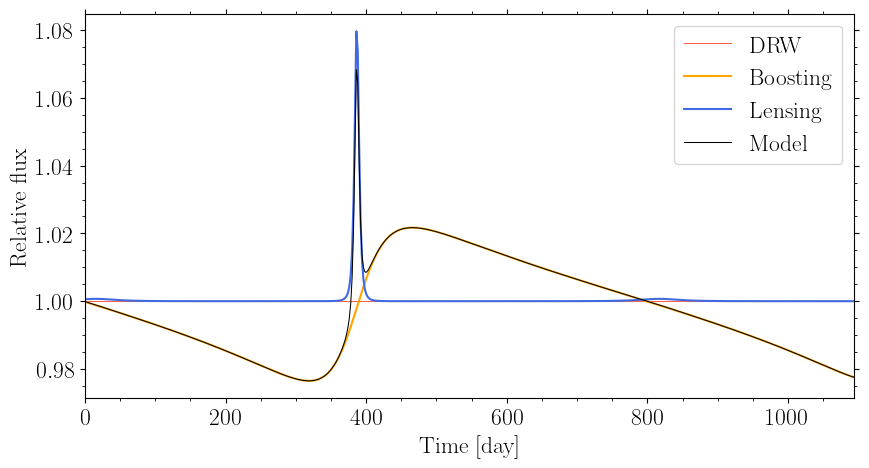

In [34]:
# Initialise model parameters and disable AGN red noise
# NOTE: the default parameters of this class is the Spikey model parameters from Hu_2025
params = smbhb.model_params()
params.sigma = 0  # Disabling AGN red noise

# Initialis======e model with model parameters
model = smbhb.model(params)

# Generate model light curve
dm = model.light_curve(time, df=True)

# Show model light curve
pt.plot_model(dm);

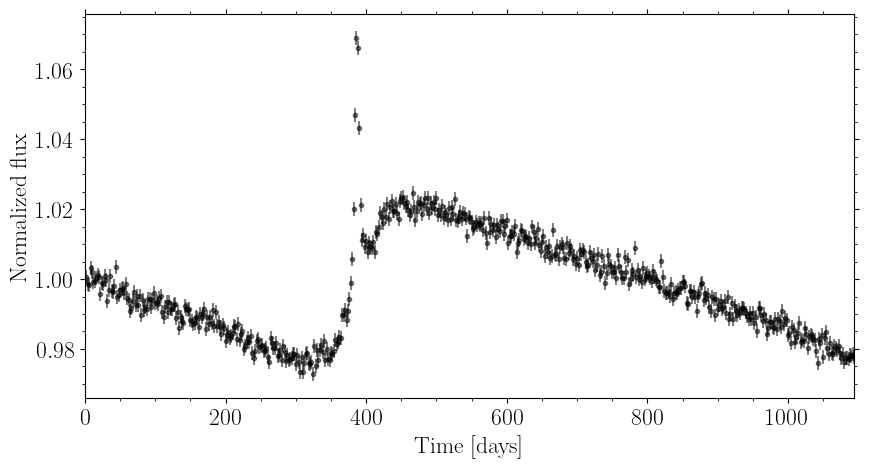

In [35]:
# Create data frame with model time series
df = pd.DataFrame()
df['time'] = dm.time
df['flux'] = dm.flux

# Add some Gaussian noise to to the model
noise_level = 2e-3           # [pp1 -> parts-per-one]
np.random.seed(params.seed)  # Reproducibility
df.flux += np.random.normal(0, noise_level, len(time))
df['flux_err'] = np.full(df.shape[0], noise_level)

# Store arrays for analysis
time     = df.time.to_numpy()
flux     = df.flux.to_numpy()
flux_err = df.flux_err.to_numpy()

# Plot "noisy" light curve
pt.plot_lc(df);

---
## 1. Model with NumPyro MCMC
---

---
## 2. UltraNest with uniform priors
---

In [22]:
# Generate relativistic Spikey model with correct parameterization
params = smbhb.model_params_q()
params.sigma = 0 
model = smbhb.model_q(params)
dm = model.light_curve(time, df=True)
params_input = [params.t0, params.P, params.i, params.e, params.w, params.logM, params.q, params.L, params.alpha]

---
### 1.2. Paramterisation using `logM` and `q`

#### *1.2.1. Uniform Priors*

In [23]:
filename = 'spikey_whitenoise_DM_bin3d_logMq_ultranest_uniform'
priors = bs.model_priors_q()
priors.z     = params.z
priors.t0    = [0.1, 3.]
priors.P     = [0.1, 3.]
priors.i     = [0.1, 89]
priors.e     = [0.1, 0.9]
priors.w     = [0.1, 359]
priors.logM  = [5., 11.]
priors.q     = [0., 1.]
priors.L     = [0., 1.]
priors.alpha = [0.1, 4.]
priors.vz    = params.vz

In [21]:
# Run UltraNest analysis
result, sampler = bs.run_ultranest_q(df, params, priors, rdir/filename)
# Show corner plot
fig = pt.plot_corner(result, bestfit='maximum', values_input=params_input);
fig.savefig(rdir / filename / 'plots' / f'{filename}_corner.png', bbox_inches='tight', dpi=200)
# Create best-fit model and plot along with data
params_model = copy.deepcopy(params)
params_model.sigma = 0
dm = bs.bestfit_model_q(time, params_model, result)
fig, ax = pt.plot_result(df, dm, Q0=12, alpha=0.3, figsize=(8.5, 6));
fig.savefig(rdir / filename / 'plots' / f'{filename}_bestfit.png', bbox_inches='tight', dpi=200)